--- Información Inicial del DataFrame ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67 entries, 0 to 66
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id_cliente             67 non-null     int64  
 1   nombre_cliente         67 non-null     object 
 2   email                  67 non-null     object 
 3   ciudad                 67 non-null     object 
 4   total_compras          67 non-null     int64  
 5   importe_total          67 non-null     int64  
 6   ticket_promedio        67 non-null     float64
 7   primera_compra         67 non-null     object 
 8   ultima_compra          67 non-null     object 
 9   dias_entre_compras     67 non-null     int64  
 10  frecuencia_compra      37 non-null     float64
 11  productos_diferentes   67 non-null     int64  
 12  categorias_diferentes  67 non-null     int64  
 13  segmento               67 non-null     object 
dtypes: float64(2), int

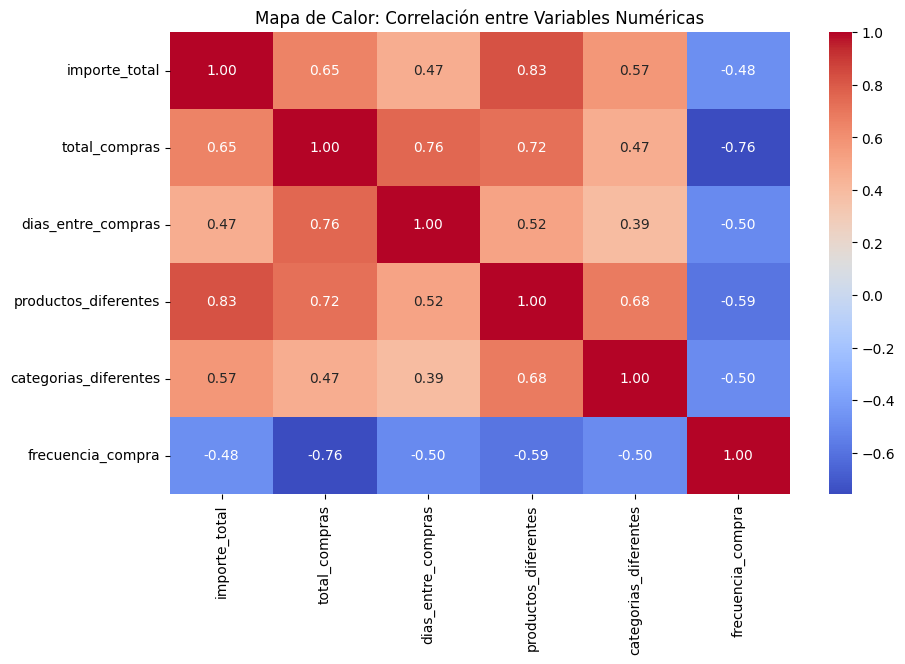

In [1]:
# =============================================================================
# BLOQUE 1: CARGA DE DATOS Y PREPROCESAMIENTO
# =============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Cargar el dataset
# Asegúrate de que el archivo esté en la misma carpeta o usa la ruta completa
df = pd.read_csv('df_clientes_ml.csv')

print("--- Información Inicial del DataFrame ---")
print(df.info())

# 2. Limpieza de Datos (Handling Missing Values)
# Asumimos que si no ha vuelto, su frecuencia es muy baja (ej. el máximo observado o un número arbitrario alto como 365 días)
max_frecuencia = df['frecuencia_compra'].max()
df['frecuencia_compra'] = df['frecuencia_compra'].fillna(max_frecuencia + 100) 
# O simplemente un valor fijo alto que tenga sentido de negocio
# df['frecuencia_compra'] = df['frecuencia_compra'].fillna(999)

# 3. Ingeniería de Características (Feature Engineering)
# Transformamos la variable categórica 'ciudad' en variables numéricas (Dummies)
# drop_first=True evita la multicolinealidad (elimina una columna redundante)
df_encoded = pd.get_dummies(df, columns=['ciudad'], drop_first=True)

# Mostramos cómo quedó la tabla transformada
print("\n--- DataFrame Transformado (Primeras 5 filas) ---")
print(df_encoded.head())

# Matriz de correlación para ver qué variables se relacionan más con el importe
plt.figure(figsize=(10, 6))
numeric_cols = ['importe_total', 'total_compras', 'dias_entre_compras', 'productos_diferentes', 'categorias_diferentes', 'frecuencia_compra']
sns.heatmap(df_encoded[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Mapa de Calor: Correlación entre Variables Numéricas')
plt.show()


--- Resultados de Regresión Lineal ---
MAE (Error absoluto medio): $304406283.00
RMSE (Error promedio): $17447.24
R2 Score (Explicación de varianza): 0.2828 (1.0 es perfecto)


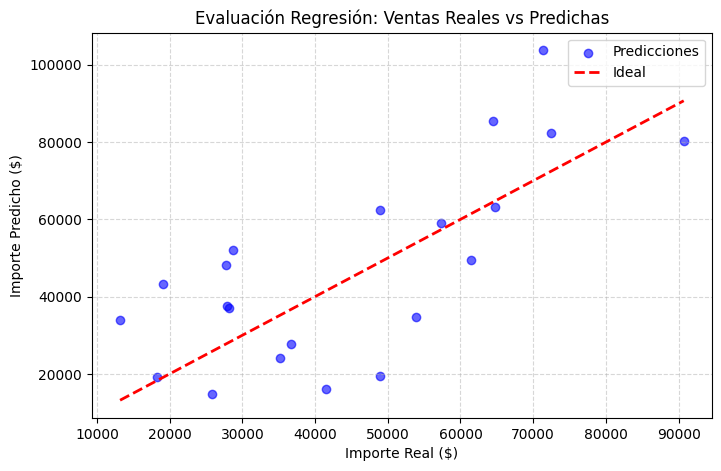

In [4]:
# =============================================================================
# BLOQUE 2: MODELO DE REGRESIÓN LINEAL (Predecir Importe)
# =============================================================================

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. Definición de X (Variables Predictoras) e y (Variable Objetivo)
# Seleccionamos variables de comportamiento y las ciudades codificadas
features_reg = ['total_compras', 'dias_entre_compras', 'productos_diferentes', 'categorias_diferentes']
# Agregamos dinámicamente las columnas de ciudad (ej. ciudad_Cordoba, ciudad_Rio Cuarto...)
features_reg += [col for col in df_encoded.columns if 'ciudad_' in col]

X_reg = df_encoded[features_reg]
y_reg = df_encoded['importe_total']

# 2. División del Dataset (Train/Test Split)
# Usamos 70% para entrenar y 30% para probar el modelo
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.3, random_state=42)

# 3. Entrenamiento del Modelo
modelo_lineal = LinearRegression()
modelo_lineal.fit(X_train_r, y_train_r)

# 4. Predicción sobre datos nuevos (Test set)
y_pred_r = modelo_lineal.predict(X_test_r)

# 5. Evaluación del Desempeño
mae = mean_squared_error(y_test_r, y_pred_r)
rmse = np.sqrt(mean_squared_error(y_test_r, y_pred_r))
r2 = r2_score(y_test_r, y_pred_r)

print(f"\n--- Resultados de Regresión Lineal ---")
print(f"MAE (Error absoluto medio): ${mae:.2f}")
print(f"RMSE (Error promedio): ${rmse:.2f}")
print(f"R2 Score (Explicación de varianza): {r2:.4f} (1.0 es perfecto)")


# 6. Visualización: Predicción vs Realidad
plt.figure(figsize=(8, 5))
plt.scatter(y_test_r, y_pred_r, color='blue', alpha=0.6, label='Predicciones')
# Línea roja de referencia (donde la predicción sería perfecta)
plt.plot([y_test_r.min(), y_test_r.max()], [y_test_r.min(), y_test_r.max()], 'r--', lw=2, label='Ideal')
plt.xlabel('Importe Real ($)')
plt.ylabel('Importe Predicho ($)')
plt.title('Evaluación Regresión: Ventas Reales vs Predichas')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Clases detectadas: ['Básico' 'Premium' 'Regular' 'VIP']

--- Resultados de Clasificación ---
Exactitud Global (Accuracy): 71.43%

Reporte Detallado por Clase:
              precision    recall  f1-score   support

      Básico       1.00      0.80      0.89         5
     Premium       0.50      0.67      0.57         3
     Regular       0.67      0.80      0.73         5
         VIP       0.00      0.00      0.00         1

    accuracy                           0.71        14
   macro avg       0.54      0.57      0.55        14
weighted avg       0.70      0.71      0.70        14



c:\Users\capab\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\capab\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\capab\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize

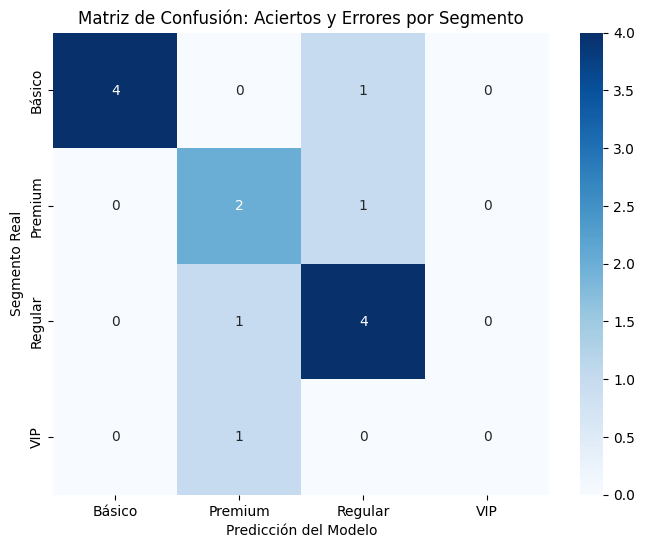

In [ ]:
# =============================================================================
# BLOQUE 3: MODELO DE REGRESIÓN LOGÍSTICA MULTICLASE (Clasificar Segmento)
# =============================================================================
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler, LabelEncoder

# 1. Preparación de X e y
# Aquí usamos 'importe_total' como entrada porque ayuda a definir el segmento
features_clf = ['importe_total', 'frecuencia_compra', 'ticket_promedio', 'productos_diferentes', 'categorias_diferentes']
features_clf += [col for col in df_encoded.columns if 'ciudad_' in col]

X_clf = df_encoded[features_clf]

# Transformamos la etiqueta de texto (y) a números (0, 1, 2...)
le = LabelEncoder()
y_clf = le.fit_transform(df_encoded['segmento'])
print(f"Clases detectadas: {le.classes_}") # Para saber qué número es cada segmento

# 2. Escalado de Datos (Estandarización)
# La regresión logística es sensible a la escala (pesos vs frecuencia). 
# StandardScaler pone todo en la misma escala.
scaler = StandardScaler()
X_clf_scaled = scaler.fit_transform(X_clf)

# 3. División Train/Test
# Usamos 80% para entrenar y 20% para probar el modelo
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_clf_scaled, y_clf, test_size=0.2, random_state=42)

# 4. Entrenamiento
# multi_class='multinomial' habilita la clasificación de más de 2 grupos
modelo_logit = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000, random_state=42)
modelo_logit.fit(X_train_c, y_train_c)

# 5. Predicción y Evaluación
y_pred_c = modelo_logit.predict(X_test_c)

accuracy = accuracy_score(y_test_c, y_pred_c)
print(f"\n--- Resultados de Clasificación ---")
print(f"Exactitud Global (Accuracy): {accuracy:.2%}")
print("\nReporte Detallado por Clase:")
print(classification_report(y_test_c, y_pred_c, target_names=le.classes_))

# 6. Visualización: Matriz de Confusión
cm = confusion_matrix(y_test_c, y_pred_c)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicción del Modelo')
plt.ylabel('Segmento Real')
plt.title('Matriz de Confusión: Aciertos y Errores por Segmento')
plt.show()

In [ ]:
# =============================================================================
# BLOQUE 4: ÁRBOL DE DECISIÓN (Clasificación de Segmento)
# =============================================================================
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# 1. Preparar datos (Asumiendo que df_encoded ya existe del Bloque 1)
features_tree = ['importe_total', 'ticket_promedio', 'frecuencia_compra', 'productos_diferentes']
features_tree += [col for col in df_encoded.columns if 'ciudad_' in col]

X_tree = df_encoded[features_tree]
y_tree = df_encoded['segmento'] # Usamos el texto directo para que el árbol sea legible

# 2. División Train/Test
# Usamos 80% para entrenar y 20% para probar el modelo
X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(X_tree, y_tree, test_size=0.2, random_state=42)

# 3. Entrenamiento
# max_depth=3 limita el árbol a 3 niveles para que sea fácil de leer (evita árboles gigantes)
clf_tree = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=42)
clf_tree.fit(X_train_t, y_train_t)

# 4. Evaluación
y_pred_t = clf_tree.predict(X_test_t)
acc_tree = accuracy_score(y_test_t, y_pred_t)

print(f"\n--- Resultados Árbol de Decisión ---")
print(f"Exactitud (Accuracy): {acc_tree:.2%}")

# 5. Visualización de Reglas
print("\n--- Reglas del Árbol (Lógica de Negocio) ---")
reglas = export_text(clf_tree, feature_names=features_tree)
print(reglas)

# Interpretación:
# "feature_0 <= 50000" significa: "Si importe_total es menor o igual a 50000..."


--- Resultados Árbol de Decisión ---
Exactitud (Accuracy): 85.71%

--- Reglas del Árbol (Lógica de Negocio) ---
|--- importe_total <= 34783.00
|   |--- frecuencia_compra <= 68.00
|   |   |--- frecuencia_compra <= 23.50
|   |   |   |--- class: Básico
|   |   |--- frecuencia_compra >  23.50
|   |   |   |--- class: Regular
|   |--- frecuencia_compra >  68.00
|   |   |--- class: Básico
|--- importe_total >  34783.00
|   |--- importe_total <= 53402.50
|   |   |--- class: Regular
|   |--- importe_total >  53402.50
|   |   |--- frecuencia_compra <= 25.35
|   |   |   |--- class: VIP
|   |   |--- frecuencia_compra >  25.35
|   |   |   |--- class: Premium



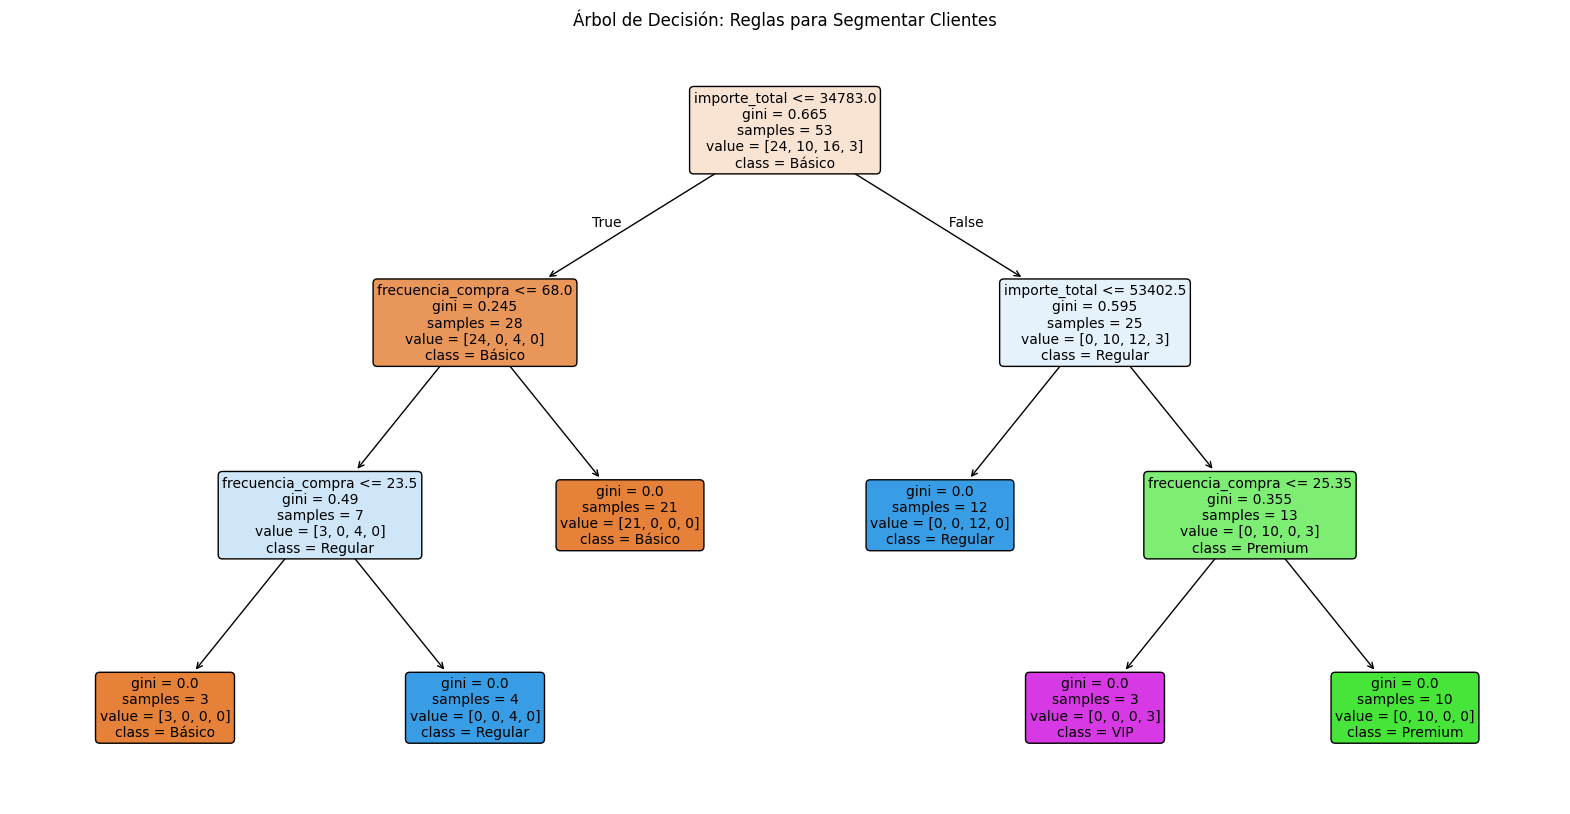

In [30]:
# =============================================================================
# BLOQUE EXTRA: VISUALIZACIÓN GRÁFICA DEL ÁRBOL
# =============================================================================
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Ajustamos el tamaño de la figura para que se lea bien (ancho, alto)
plt.figure(figsize=(20, 10))

# Generamos el gráfico
plot_tree(clf_tree, 
          feature_names=features_tree,  # Nombres de las variables (X)
          class_names=clf_tree.classes_, # Nombres de los segmentos (y)
          filled=True,                  # Colorea los nodos según la clase dominante
          rounded=True,                 # Bordes redondeados (estético)
          fontsize=10)                  # Tamaño de letra

plt.title("Árbol de Decisión: Reglas para Segmentar Clientes")
plt.show()